# Usage

This notebook contains two basic `blackmarblepy` usage examples: retrieving a raster and extracting zonal statistics.

## Setup

Run this cell first. It loads the required packages, finds the repository root, loads Nigeria boundaries, and reads your NASA Earthdata bearer token from `~/.config/ntl-training/secrets.env`. If the token is not found, the notebook prompts for it and saves it locally.

### Import Libraries

Please wait upto 1 minute for this to finish running. 

In [2]:
import os
from pathlib import Path
from getpass import getpass

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray  # noqa: F401 - registers the .rio accessor
from dotenv import dotenv_values
from shapely.geometry import box

from blackmarble import BlackMarble, Product

Remember to add your own token after this session. The existing token will be invalidated. 

In [8]:
def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "data").exists() and (path / "spatial-blackmarble-training").exists():
            return path
    return start


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
RAW_DIR = DATA_DIR / "ntl_blackmarble" / "nigeria" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

secrets_path = REPO_ROOT / ".config" / "ntl-training" / "secrets.env"
secrets = dotenv_values(secrets_path)
blackmarble_token = secrets.get("BLACKMARBLE_TOKEN", "").strip()




In [9]:
bm = BlackMarble(
    token=blackmarble_token,
    output_directory=None,
    output_skip_if_exists=True,
)

Read administrative boundaries. You can get these admin boudnaries from your chosen source.

In [5]:
adm0 = gpd.read_file(DATA_DIR / "gadm" / "nga_adm0.geojson")
adm1 = gpd.read_file(DATA_DIR / "gadm" / "nga_adm1.geojson")

for gdf in [adm0, adm1]:
    gdf["geometry"] = gdf.geometry.make_valid()

adm0 = adm0.to_crs("EPSG:4326")
adm1 = adm1.to_crs("EPSG:4326")

# Download against a simple bounding box around Nigeria.
adm0_bbox = gpd.GeoDataFrame(geometry=[box(*adm0.total_bounds)], crs=adm0.crs)

## `raster()`

Retrieve a monthly Black Marble raster for January 2024 and plot the log of nighttime lights.

['h18v07', 'h18v08', 'h19v07', 'h19v08']
['h18v07', 'h18v08', 'h19v07', 'h19v08']
['https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2024001.h18v07.002.2025161151918.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2024001.h18v08.002.2025161151844.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2024001.h19v07.002.2025161151908.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A3.A2024001.h19v08.002.2025161151914.h5']


  0%|          | 0.00/65.3M [00:00<?, ?B/s]

  0%|          | 0.00/72.8M [00:00<?, ?B/s]

  0%|          | 0.00/64.1M [00:00<?, ?B/s]

  0%|          | 0.00/65.2M [00:00<?, ?B/s]

COLLATING TILES | Processing...:   0%|          | 0/1 [00:00<?, ?date/s]

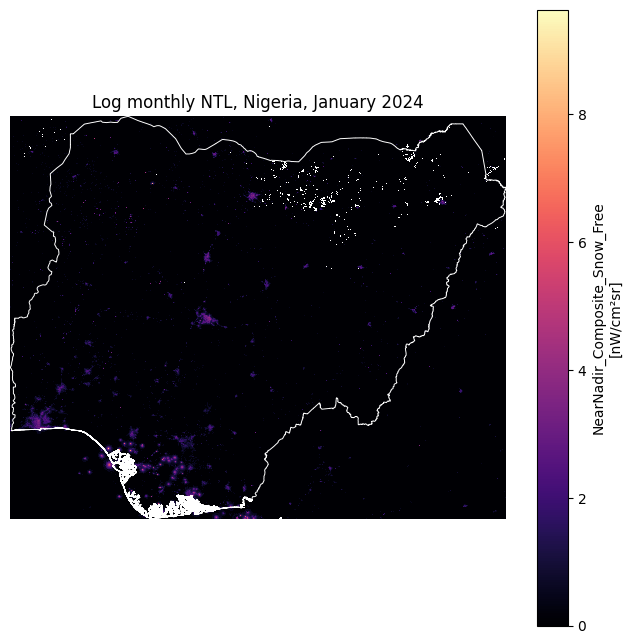

In [10]:
ntl = bm.raster(
    adm0_bbox,
    product_id=Product.VNP46A3,
    date_range=pd.date_range("2024-01-01", "2024-01-01", freq="MS"),
)

ntl_da = ntl["NearNadir_Composite_Snow_Free"].squeeze()
ntl_log = np.log1p(ntl_da)

fig, ax = plt.subplots(figsize=(8, 8))
ntl_log.plot(ax=ax, cmap="magma", add_colorbar=True)
adm0.boundary.plot(ax=ax, color="white", linewidth=0.7)
ax.set_title("Log monthly NTL, Nigeria, January 2024")
ax.set_axis_off()
plt.show()

## `extract()`

Retrieve annual Black Marble data from 2012 to 2024 and aggregate the sum of nighttime lights for Nigeria's ADM1 polygons.

In [12]:
ntl_adm1 = bm.extract(
    adm1,
    product_id=Product.VNP46A4,
    date_range=pd.date_range("2023-01-01", "2024-01-01", freq="YS"),
)

ntl_adm1.head()

['h18v07', 'h18v08', 'h19v07', 'h19v08']
['h18v07', 'h18v08', 'h19v07', 'h19v08']
['https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2023001.h18v07.002.2025161113010.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2024001.h18v07.002.2025162031135.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2023001.h18v08.002.2025161113203.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2024001.h18v08.002.2025162031854.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2024001.h19v07.002.2025162121907.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2023001.h19v07.002.2025161112717.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2024001.h19v08.002.2025162033234.h5', 'https://ladsweb.modaps.eosdis.nasa.gov/api/v2/content/archives/VNP46A4.A2023001.h19v08.002.2025161112653.h5']


  0%|          | 0.00/72.4M [00:00<?, ?B/s]

  0%|          | 0.00/73.7M [00:00<?, ?B/s]

  0%|          | 0.00/85.5M [00:00<?, ?B/s]

  0%|          | 0.00/86.0M [00:00<?, ?B/s]

...

  0%|          | 0.00/71.3M [00:00<?, ?B/s]

  0%|          | 0.00/80.1M [00:00<?, ?B/s]

  0%|          | 0.00/77.5M [00:00<?, ?B/s]

COLLATING TILES | Processing...:   0%|          | 0/2 [00:00<?, ?date/s]

,NAME_1,geometry,ntl_sum,date
0,Abia,"POLYGON ((7.46283 4.98177, 7.46261 4.96793, 7....",8502.373002,2023-01-01
1,Adamawa,"POLYGON ((12.25072 8.17262, 12.24873 8.1702, 1...",4613.351352,2023-01-01
2,Akwa Ibom,"MULTIPOLYGON (((8.31958 4.55764, 8.31958 4.557...",29453.910214,2023-01-01
3,Anambra,"POLYGON ((6.93577 5.85795, 6.93626 5.84572, 6....",22927.189554,2023-01-01
4,Bauchi,"POLYGON ((9.75266 9.60087, 9.73536 9.5673, 9.7...",3732.706936,2023-01-01
